### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from collections import Counter
from wordcloud import WordCloud, STOPWORDS
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

### 2. Load Dataset

In [3]:
path = r"../data/raw/training.1600000.processed.noemoticon.csv"

data = pd.read_csv(path, encoding="latin1")

In [4]:
df = pd.DataFrame(data)
df.columns = ["Label", "Serial", "Date", "Query", "Twitter_id", "Tweet"]

### 3. Dataset Overview

In [5]:
df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [6]:
df.tail()

,Label,Serial,Date,Query,Twitter_id,Tweet
1599994,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599995,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599996,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599997,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...
1599998,4,2193602129,Tue Jun 16 08:40:50 PDT 2009,NO_QUERY,RyanTrevMorris,happy #charitytuesday @theNSPCC @SparksCharity...


In [7]:
df.shape

(1599999, 6)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Label       1599999 non-null  int64 
 1   Serial      1599999 non-null  int64 
 2   Date        1599999 non-null  object
 3   Query       1599999 non-null  object
 4   Twitter_id  1599999 non-null  object
 5   Tweet       1599999 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [9]:
df.describe()

,Label,Serial
count,1.599999e+06,1.599999e+06
mean,2.000001e+00,1.998818e+09
std,2.000001e+00,1.935757e+08
min,0.000000e+00,1.467811e+09
25%,0.000000e+00,1.956916e+09
50%,4.000000e+00,2.002102e+09
75%,4.000000e+00,2.177059e+09
max,4.000000e+00,2.329206e+09


In [10]:
df.describe(include="all")

,Label,Serial,Date,Query,Twitter_id,Tweet
count,1.599999e+06,1.599999e+06,1599999,1599999,1599999,1599999
unique,NaN,NaN,774362,1,659775,1581465
top,NaN,NaN,Mon Jun 15 12:53:14 PDT 2009,NO_QUERY,lost_dog,isPlayer Has Died! Sorry
freq,NaN,NaN,20,1599999,549,210
mean,2.000001e+00,1.998818e+09,NaN,NaN,NaN,NaN
std,2.000001e+00,1.935757e+08,NaN,NaN,NaN,NaN
min,0.000000e+00,1.467811e+09,NaN,NaN,NaN,NaN
25%,0.000000e+00,1.956916e+09,NaN,NaN,NaN,NaN
50%,4.000000e+00,2.002102e+09,NaN,NaN,NaN,NaN
75%,4.000000e+00,2.177059e+09,NaN,NaN,NaN,NaN


### 4. Missing Values Analysis

In [11]:
df.isnull().sum()

Label         0
Serial        0
Date          0
Query         0
Twitter_id    0
Tweet         0
dtype: int64

In [12]:
df.isna().sum()

Label         0
Serial        0
Date          0
Query         0
Twitter_id    0
Tweet         0
dtype: int64

In [13]:
df["Tweet"].isnull()

0          False
1          False
2          False
3          False
4          False
           ...  
1599994    False
1599995    False
1599996    False
1599997    False
1599998    False
Name: Tweet, Length: 1599999, dtype: bool

In [14]:
df.notnull().sum()

Label         1599999
Serial        1599999
Date          1599999
Query         1599999
Twitter_id    1599999
Tweet         1599999
dtype: int64

In [15]:
df.isnull().sum(axis=1)
# df.isnull().sum(axis="rows")

0          0
1          0
2          0
3          0
4          0
          ..
1599994    0
1599995    0
1599996    0
1599997    0
1599998    0
Length: 1599999, dtype: int64

### 5. Class Distribution

In [16]:
df["Label"].value_counts()

Label
4    800000
0    799999
Name: count, dtype: int64

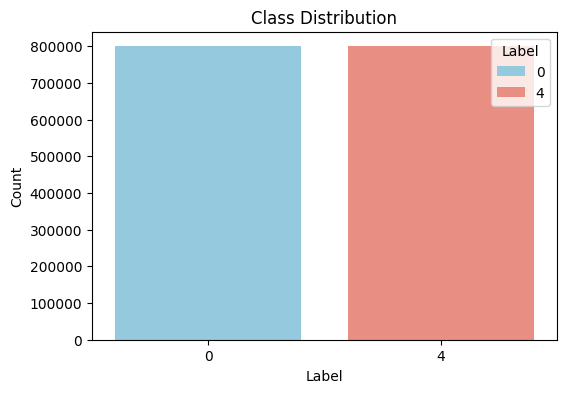

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Label", data=df, hue="Label", palette=["skyblue", "salmon"])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### 6. Convert Labels

In [18]:
df.loc[df["Label"] == 4, "Label"] = 1

In [19]:
df["Label"].value_counts()

Label
1    800000
0    799999
Name: count, dtype: int64

### 7. Sample Tweets

In [20]:
df.loc[df["Label"] == 0, "Tweet"].sample(5)

434990    @ggette whatever. I called you pa. Texted you ...
302948    I have been decieved for all these years HIP H...
691310    @taasshhh which day..saturday ?..i think ill b...
514685    @ostemb0r will be all over then bro  shame was...
760198    Guess what, VZ &quot;New Every Two&quot; isn't...
Name: Tweet, dtype: object

In [21]:
df.loc[df["Label"]==1, "Tweet"].sample(5)

1277463              off to conduct again - see you after  x
1111387                   Bowling, bbq, and swimming today! 
1428207    @auntiedis  That would put a unique twist on i...
1586427      @xxSmileeeeexx thank youuu  i feel soooo luved 
818039     @AnonymousDave I am very happy that AA is work...
Name: Tweet, dtype: object

### 8. Text Length Analysis

In [22]:
df["Length"] = df["Tweet"].str.len()
df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29


In [23]:
data = df["Length"]

lenght_mean = np.mean(data)
print(f"{lenght_mean:.2f}")

74.09


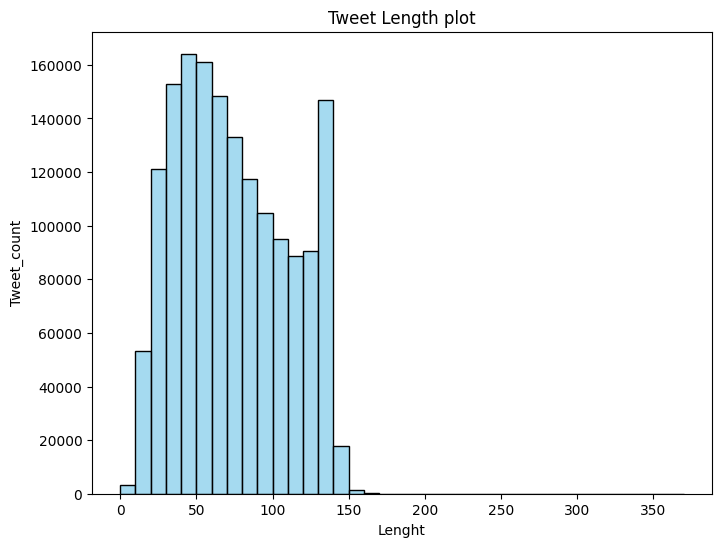

In [24]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df["Length"], color="skyblue", 
             bins=np.arange(0, df["Length"].max(), 10))
plt.title("Tweet Length plot")
plt.xlabel("Lenght")
plt.ylabel("Tweet_count")
plt.show()

In [25]:
max_length = df["Length"].max()
min_lenght = df["Length"].min()

print(f"The longest tweet has {max_length} words.")
print(f"The shortest tweet has {min_lenght} words.")

The longest tweet has 374 words.
The shortest tweet has 6 words.


### 9. Negative/Positive Distribution

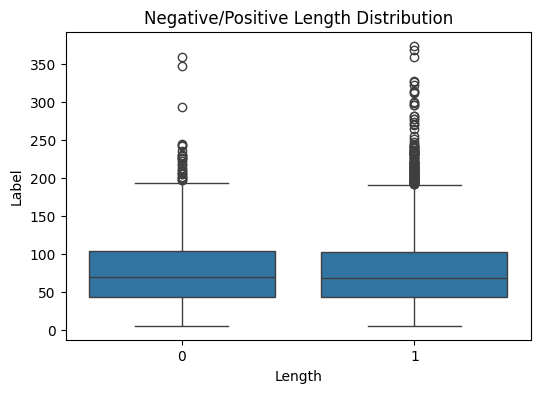

In [26]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Label", y="Length")
plt.title("Negative/Positive Length Distribution")
plt.xlabel("Length")
plt.ylabel("Label")
plt.show()

### 9. URL Analysis

In [27]:
url_pattern = r"https?://\S"

df["Url_Count"] = df["Tweet"].fillna("").str.count(url_pattern)

df["Url_Count"]

0          0
1          0
2          0
3          0
4          0
          ..
1599994    0
1599995    1
1599996    0
1599997    0
1599998    0
Name: Url_Count, Length: 1599999, dtype: int64

In [28]:
print(df["Url_Count"].describe())

count    1.599999e+06
mean     4.471440e-02
std      2.115244e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e+00
Name: Url_Count, dtype: float64


In [29]:
url_count = df["Url_Count"].gt(0).sum()
print(f"There are {url_count} Tweets with at least on url.")

There are 70110 Tweets with at least on url.


###  10. Mention Analysis

In [30]:
pattern = r"@\w+"

df["Mentions"] = df["Tweet"].fillna("").str.findall(pattern)

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[]
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan]
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[]
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass]
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei]


In [31]:
df["Mentions_Count"] = df["Mentions"].str.len()

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1


In [32]:
mentions_count1 = df["Mentions_Count"].eq(1).sum()
mentions_count2 = df["Mentions_Count"].gt(1).sum()

print(f"There are {mentions_count1} tweets with exacly one mention.")
print(f"There are {mentions_count2} tweets with more than one mention.")

There are 704274 tweets with exacly one mention.
There are 34218 tweets with more than one mention.


In [33]:
negative_mentions_count = ((df["Label"]==0) & (df["Mentions_Count"]>0)).sum()
positive_mentions_count = ((df["Label"]==1) & (df["Mentions_Count"]>0)).sum()

print(f"Ther are {negative_mentions_count} negative tweets with at least one mention.")
print(f"Ther are {positive_mentions_count} positive tweets with at least one mention.")

Ther are 300841 negative tweets with at least one mention.
Ther are 437651 positive tweets with at least one mention.


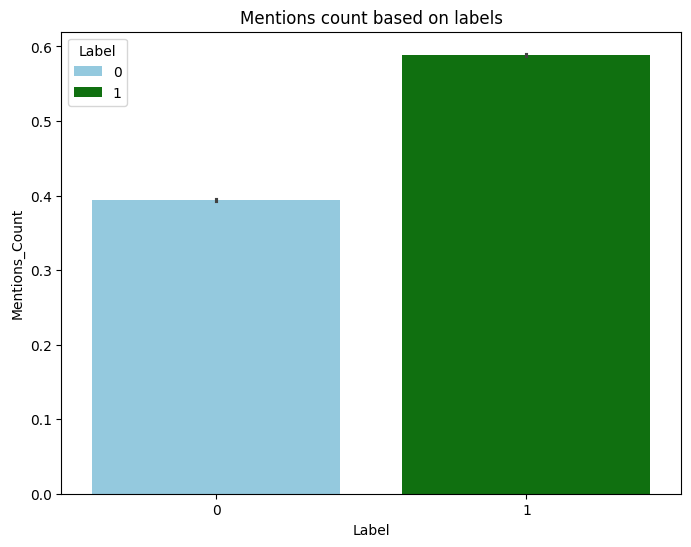

In [34]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Label", y="Mentions_Count", hue="Label", palette=("skyblue", "green"))
plt.title("Mentions count based on labels")
plt.xlabel("Label")
plt.ylabel("Mentions_Count")
plt.show()

###  11. Hashtag Analysis

In [35]:
hashtag_pattern=r"#\w+"

df["Hashtags"] = df["Tweet"].fillna("").str.findall(hashtag_pattern)

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count,Hashtags
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0,[]
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1,[]
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0,[]
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1,[]
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1,[]


In [36]:
df["Hashtags_Count"] = df["Hashtags"].str.len()

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count,Hashtags,Hashtags_Count
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0,[],0
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1,[],0
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0,[],0
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1,[],0
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1,[],0


In [37]:
hashtag_count1 = df["Hashtags_Count"].eq(1).sum()
hashtag_count2 = df["Hashtags_Count"].gt(1).sum()

print(f"There are {hashtag_count1} tweets with exactly one hashtag.")
print(f"There are {hashtag_count2} tweets with more than one hashtag.")

There are 31073 tweets with exactly one hashtag.
There are 4774 tweets with more than one hashtag.


In [38]:
positive_hashtag_count = ((df["Label"] == 1) & (df["Hashtags_Count"] > 0)).sum()
negative_hashtag_count = ((df["Label"] == 0) & (df["Hashtags_Count"] > 0)).sum()

print(f"There are {positive_hashtag_count} positive tweets with at least one hashtag.")
print(f"There are {negative_hashtag_count} negative tweets with at least one hashtag.")

There are 20634 positive tweets with at least one hashtag.
There are 15213 negative tweets with at least one hashtag.


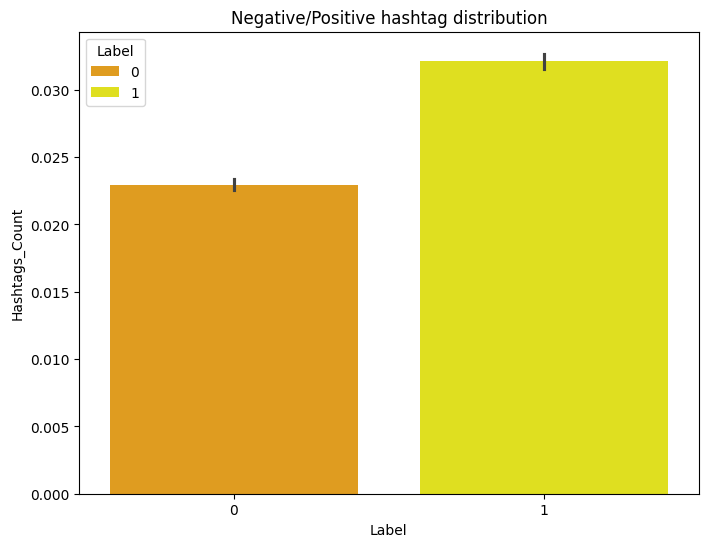

In [39]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Label", y="Hashtags_Count", hue="Label", palette=("orange", "yellow"))
plt.title("Negative/Positive hashtag distribution")
plt.xlabel("Label")
plt.ylabel("Hashtags_Count")
plt.show()

### 12. Punctuation Marks Analysis

In [40]:
question_pattern = r"\?"

question_marks = df["Tweet"].fillna("").str.findall(question_pattern)

question_marks

0           []
1           []
2           []
3          [?]
4           []
          ... 
1599994     []
1599995     []
1599996    [?]
1599997     []
1599998     []
Name: Tweet, Length: 1599999, dtype: object

In [41]:
df["Question_Count"] = question_marks.str.len()

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count,Hashtags,Hashtags_Count,Question_Count
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0,[],0,0
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1,[],0,0
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0,[],0,0
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1,[],0,1
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1,[],0,0


In [42]:
question_count1 = df["Question_Count"].eq(1).sum()
question_count2 = df["Question_Count"].gt(1).sum()

print(f"There are {question_count1} tweets with exactly one ? mark.")
print(f"There are {question_count2} tweets with more than one ? mark.")

There are 129652 tweets with exactly one ? mark.
There are 37656 tweets with more than one ? mark.


In [43]:
positive_questionmark_count = ((df["Label"] == 1) & (df["Question_Count"] > 0)).sum()
negative_question_mark_count = ((df["Label"] == 0) & (df["Question_Count"] > 0)).sum()

print(f"There are {positive_questionmark_count} positive tweets with at least one ? mark.")
print(f"There are {negative_question_mark_count} negative tweets with at least one ? mark.")

There are 86093 positive tweets with at least one ? mark.
There are 81215 negative tweets with at least one ? mark.


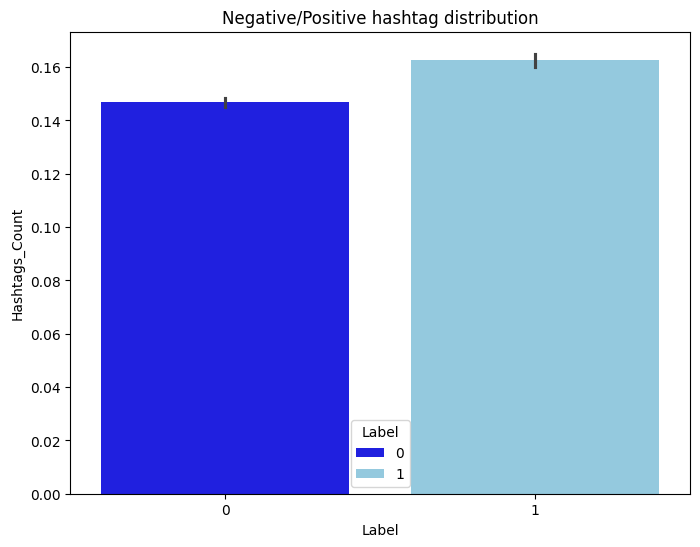

In [44]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Label", y="Question_Count", hue="Label", palette=("blue", "skyblue"))
plt.title("Negative/Positive hashtag distribution")
plt.xlabel("Label")
plt.ylabel("Hashtags_Count")
plt.show()

In [45]:
exc_pattern = r"!"

exclamation_mark = df["Tweet"].fillna("").str.findall(exc_pattern)

exclamation_mark

0                [!]
1                 []
2                 []
3                 []
4                 []
             ...    
1599994           []
1599995          [!]
1599996           []
1599997    [!, !, !]
1599998           []
Name: Tweet, Length: 1599999, dtype: object

In [46]:
df["Exclamation_Count"] = exclamation_mark.str.len()

df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count,Hashtags,Hashtags_Count,Question_Count,Exclamation_Count
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0,[],0,0,1
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1,[],0,0,0
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0,[],0,0,0
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1,[],0,1,0
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1,[],0,0,0


In [47]:
exlamation_count1 = df["Exclamation_Count"].eq(0).sum()
exlamation_count2 = df["Exclamation_Count"].gt(1).sum()

print(f"There are {exlamation_count1} tweets with exactly one ! mark.")
print(f"There are {exlamation_count2} tweets with more than one ! mark.")

There are 1118620 tweets with exactly one ! mark.
There are 203239 tweets with more than one ! mark.


In [48]:
positive_exclamationmark_count = ((df["Label"] == 1) & (df["Exclamation_Count"] > 0)).sum()
negative_exclamationmark_count = ((df["Label"] == 0) & (df["Exclamation_Count"] > 0)).sum()

print(f"There are {positive_exclamationmark_count} positive tweets with at least one ! mark.")
print(f"There are {negative_exclamationmark_count} negative tweets with at least one ! mark.")

There are 283031 positive tweets with at least one ! mark.
There are 198348 negative tweets with at least one ! mark.


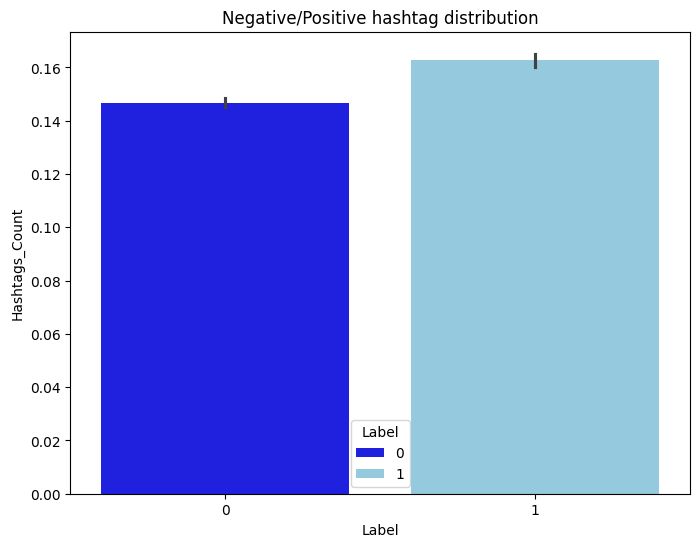

In [49]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Label", y="Question_Count", hue="Label", palette=("blue", "skyblue"))
plt.title("Negative/Positive hashtag distribution")
plt.xlabel("Label")
plt.ylabel("Hashtags_Count")
plt.show()

### 13. Emoji Analysis

In [50]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    u"\U0001F926-\U0001F937"
    u"\U00010000-\U0010ffff"
    u"\u200d"
    u"\u2640-\u2642"
    u"\u2600-\u2B55"
    u"\u23cf"
    u"\u23e9"
    u"\u231a"
    u"\u3030"
    u"\ufe0f"
    u"\u2069"
    u"\u2066"
    u"\u200c"
    u"\u2068"
    u"\u2067"
    "]+",
    flags=re.UNICODE
)

df["Emojies"] = df["Tweet"].fillna("").str.findall(emoji_pattern)

In [51]:
emoji_count = df["Emojies"].str.len().gt(0).sum()
print(f"There are {emoji_count} emojies in tweets.")

There are 0 emojies in tweets.


### 13. Top Words

In [52]:
all_tweets = df["Tweet"].fillna("").str.lower()

big_text = " ".join(all_tweets)

step_words = set(STOPWORDS)

words = [words for words in big_text.split() if words not in step_words]

top_words = pd.Series(words).value_counts()
top_words

good               77367
-                  67078
go                 66733
now                63269
going              62290
                   ...  
nemuselo               1
@myheartandmind        1
@shebbs123             1
@bizcoachdeb           1
aree,                  1
Name: count, Length: 1193391, dtype: int64

In [53]:
top_words[0: 21]

good      77367
-         67078
go        66733
now       63269
going     62290
got       60453
day       60232
love      60141
will      50550
back      49482
im        48473
u         48362
work      48194
really    46183
one       44773
see       43831
time      43664
know      42280
still     41425
new       41313
want      40989
Name: count, dtype: int64

In [54]:
print(f"Total number of stepwords: {len(step_words)}")

Total number of stepwords: 192


###  14. WordCloud

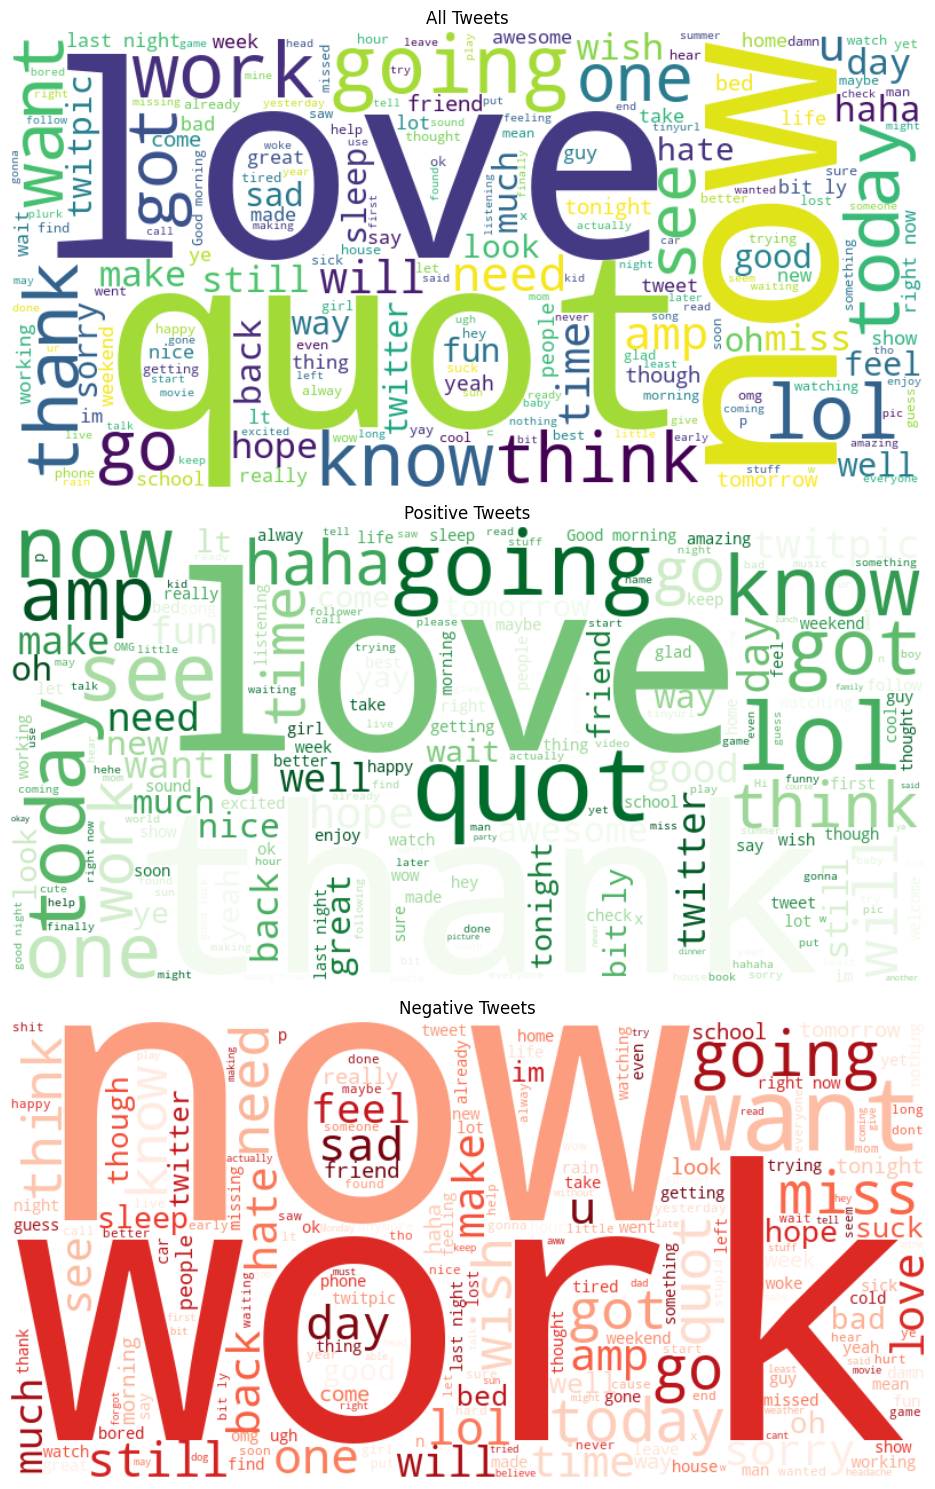

In [55]:
all_text = " ".join(df["Tweet"].fillna("").astype(str))
positive_text = " ".join(df.loc[df["Label"] == 1, "Tweet"].fillna("").astype(str))
negative_text = " ".join(df.loc[df["Label"] == 0, "Tweet"].fillna("").astype(str))

stopwords = set(STOPWORDS)

wc_all = WordCloud(width=800, height=400, background_color="White",
                   stopwords=stopwords).generate(all_text)

wc_positive = WordCloud(width=800, height=400, background_color="White",
                        colormap="Greens", stopwords=stopwords).generate(positive_text)

wc_negative = WordCloud(width=800, height=400, background_color="White",
                   colormap="Reds", stopwords=stopwords).generate(negative_text)


fig, axes = plt.subplots(3, 1, figsize=(12, 15))

axes[0].imshow(wc_all, interpolation="bilinear")
axes[0].set_title("All Tweets")
axes[0].axis("off")


axes[1].imshow(wc_positive, interpolation="bilinear")
axes[1].set_title("Positive Tweets")
axes[1].axis("off")


axes[2].imshow(wc_negative, interpolation="bilinear")
axes[2].set_title("Negative Tweets")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 15. Bigrams and Trigrams

In [56]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Parsa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [57]:
positive_tokens = word_tokenize(positive_text.lower())
positive_tokens = [word for word in positive_tokens if word not in step_words]

bigrams = list(ngrams(positive_tokens, 2))
bigrams_freq = Counter(bigrams)

trigrams = list(ngrams(positive_tokens, 3))
trigrams_freq = Counter(trigrams)

print(f"Top 10 bigrams: {bigrams_freq.most_common(10)}")
print(f"Top 10 trigrams: {trigrams_freq.most_common(10)}")

Top 10 bigrams: [(('!', '!'), 148941), (('!', '@'), 80201), (('.', '@'), 60815), (('quot', ';'), 45931), (('&', 'quot'), 45930), (('?', '?'), 28486), (('amp', ';'), 26226), (('&', 'amp'), 26218), (('?', '@'), 19836), (('ca', "n't"), 14125)]
Top 10 trigrams: [(('!', '!', '!'), 68301), (('&', 'quot', ';'), 45930), (('&', 'amp', ';'), 26218), (('?', '?', '?'), 18123), (('!', '!', '@'), 17266), (('&', 'lt', ';'), 11582), (('lt', ';', '3'), 8182), (('ca', "n't", 'wait'), 7482), (('&', 'gt', ';'), 3731), (('!', 'ca', "n't"), 2634)]


In [ ]:
negative_tokens = word_tokenize(negative_text.lower())
negative_tokens = [word for word in negative_tokens if word not in step_words]

bigrams = list(ngrams(negative_tokens, 2))
bigrams_freq = Counter(bigrams)

trigrams = list(ngrams(negative_tokens, 3))
trigrams_freq = Counter(trigrams)

print(f"Top 10 negative bigrams: {bigrams_freq}")
print(f"Top 10 negative trigrams: {trigrams_freq}")

### 16. Correlation Analysis

In [ ]:
df.head()

,Label,Serial,Date,Query,Twitter_id,Tweet,Length,Url_Count,Mentions,Mentions_Count,Hashtags,Hashtags_Count,Question_Count,Exclamation_Count,Emojies
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,0,[],0,[],0,0,1,[]
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,0,[@Kenichan],1,[],0,0,0,[]
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,0,[],0,[],0,0,0,[]
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,0,[@nationwideclass],1,[],0,1,0,[]
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,29,0,[@Kwesidei],1,[],0,0,0,[]


In [ ]:
data = df["Mentions_Count", "Hashtags_Count", "Question_Count", "Exclamation_Count"]

plt.figure(figsize=(8, 6))
sns.heatmap(data=data, annot=True, fmt=".1f")
plt.title("Correlation Analysis")
plt.show()

KeyError: ('Mentions_Count', 'Hashtags_Count', 'Question_Count', 'Exclamation_Count')